# Understanding the Bihistogram

A **bihistogram** places two histograms back-to-back (one above and one below a shared x-axis) so you can compare the distributions of two groups at a glance. It is the two-sample equivalent of a histogram: same x-axis for both groups, bars grow upward for group 1 and downward for group 2. This makes it easy to spot differences in location, spread, skewness, and shape that would be harder to compare side-by-side.

The bihistogram is a standard graphical test of the **two-sample problem**: "Do these two datasets come from the same distribution?"

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

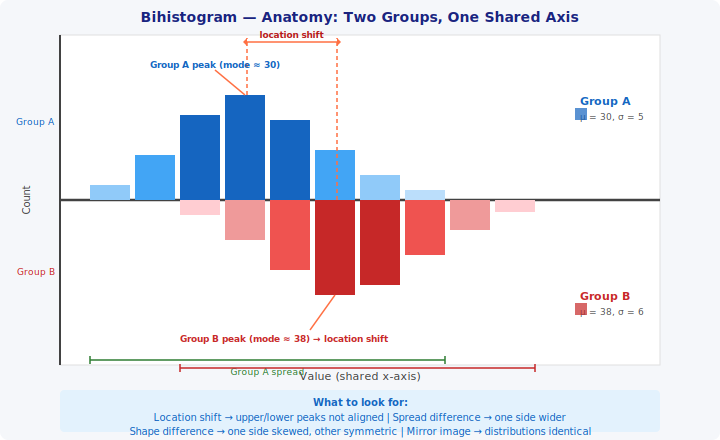

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="720" height="440"
     font-family="'Segoe UI', Arial, sans-serif">
  <rect width="720" height="440" fill="#F5F7FA" rx="8"/>
  <text x="360" y="22" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Bihistogram — Anatomy: Two Groups, One Shared Axis</text>

  <!-- plot area -->
  <rect x="60" y="35" width="600" height="330" fill="white" stroke="#E0E0E0"/>

  <!-- Shared x-axis (centre line) -->
  <line x1="60" y1="200" x2="660" y2="200" stroke="#424242" stroke-width="2.5"/>
  <text x="360" y="380" text-anchor="middle" font-size="11" fill="#424242">Value (shared x-axis)</text>

  <!-- y-axis -->
  <line x1="60" y1="35" x2="60" y2="365" stroke="#424242" stroke-width="2"/>

  <!-- Y labels -->
  <text x="55" y="125" text-anchor="end" font-size="9" fill="#1565C0">Group A</text>
  <text x="55" y="275" text-anchor="end" font-size="9" fill="#C62828">Group B</text>
  <text x="30" y="200" text-anchor="middle" font-size="10" fill="#424242"
        transform="rotate(-90 30 200)">Count</text>

  <!-- ── GROUP A bars (grow upward from centre) — shifted right ── -->
  <rect x="90"  y="185" width="40" height="15"  fill="#90CAF9"/>
  <rect x="135" y="155" width="40" height="45"  fill="#42A5F5"/>
  <rect x="180" y="115" width="40" height="85"  fill="#1565C0"/>
  <rect x="225" y="95"  width="40" height="105" fill="#1565C0"/>
  <rect x="270" y="120" width="40" height="80"  fill="#1565C0"/>
  <rect x="315" y="150" width="40" height="50"  fill="#42A5F5"/>
  <rect x="360" y="175" width="40" height="25"  fill="#90CAF9"/>
  <rect x="405" y="190" width="40" height="10"  fill="#BBDEFB"/>

  <!-- Group A label -->
  <text x="580" y="105" font-size="11" font-weight="bold" fill="#1565C0">Group A</text>
  <text x="580" y="120" font-size="9" fill="#555">μ = 30, σ = 5</text>
  <rect x="575" y="108" width="12" height="12" fill="#1565C0" opacity="0.7"/>

  <!-- ── GROUP B bars (grow downward from centre) — shifted left ── -->
  <rect x="180" y="200" width="40" height="15"  fill="#FFCDD2"/>
  <rect x="225" y="200" width="40" height="40"  fill="#EF9A9A"/>
  <rect x="270" y="200" width="40" height="70"  fill="#EF5350"/>
  <rect x="315" y="200" width="40" height="95"  fill="#C62828"/>
  <rect x="360" y="200" width="40" height="85"  fill="#C62828"/>
  <rect x="405" y="200" width="40" height="55"  fill="#EF5350"/>
  <rect x="450" y="200" width="40" height="30"  fill="#EF9A9A"/>
  <rect x="495" y="200" width="40" height="12"  fill="#FFCDD2"/>

  <!-- Group B label -->
  <text x="580" y="300" font-size="11" font-weight="bold" fill="#C62828">Group B</text>
  <text x="580" y="315" font-size="9" fill="#555">μ = 38, σ = 6</text>
  <rect x="575" y="303" width="12" height="12" fill="#C62828" opacity="0.7"/>

  <!-- ANNOTATIONS -->
  <!-- Location shift -->
  <line x1="247" y1="95" x2="247" y2="38" stroke="#FF7043" stroke-width="1.5" stroke-dasharray="4,3"/>
  <line x1="337" y1="200" x2="337" y2="38" stroke="#FF7043" stroke-width="1.5" stroke-dasharray="4,3"/>
  <line x1="247" y1="42" x2="337" y2="42" stroke="#FF7043" stroke-width="1.5"/>
  <polygon points="247,38 247,46 243,42" fill="#FF7043"/>
  <polygon points="337,38 337,46 341,42" fill="#FF7043"/>
  <text x="292" y="38" text-anchor="middle" font-size="9" font-weight="bold" fill="#B71C1C">location shift</text>

  <!-- A peak annotation -->
  <line x1="245" y1="95" x2="215" y2="70" stroke="#FF7043" stroke-width="1.5"/>
  <text x="150" y="68" font-size="9" font-weight="bold" fill="#1565C0">Group A peak (mode ≈ 30)</text>

  <!-- B peak annotation -->
  <line x1="335" y1="295" x2="310" y2="330" stroke="#FF7043" stroke-width="1.5"/>
  <text x="180" y="342" font-size="9" font-weight="bold" fill="#C62828">Group B peak (mode ≈ 38) → location shift</text>

  <!-- Spread difference -->
  <line x1="90"  y1="360" x2="445" y2="360" stroke="#2E7D32" stroke-width="1.5"/>
  <line x1="90"  y1="356" x2="90"  y2="364" stroke="#2E7D32" stroke-width="1.5"/>
  <line x1="445" y1="356" x2="445" y2="364" stroke="#2E7D32" stroke-width="1.5"/>
  <text x="267" y="375" text-anchor="middle" font-size="9" fill="#2E7D32">Group A spread</text>
  <line x1="180" y1="368" x2="535" y2="368" stroke="#C62828" stroke-width="1.5"/>
  <line x1="180" y1="364" x2="180" y2="372" stroke="#C62828" stroke-width="1.5"/>
  <line x1="535" y1="364" x2="535" y2="372" stroke="#C62828" stroke-width="1.5"/>

  <!-- Takeaway -->
  <rect x="60" y="390" width="600" height="42" fill="#E3F2FD" rx="4"/>
  <text x="360" y="406" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">What to look for:</text>
  <text x="360" y="421" text-anchor="middle" font-size="10" fill="#1565C0">Location shift → upper/lower peaks not aligned   |   Spread difference → one side wider</text>
  <text x="360" y="435" text-anchor="middle" font-size="10" fill="#1565C0">Shape difference → one side skewed, other symmetric   |   Mirror image → distributions identical</text>
</svg>
"""
display(SVG(_svg))

## Interpreting a Bihistogram

| Pattern | What it means |
|---|---|
| **Peaks aligned** | Same location — distributions may have the same mean |
| **Peaks offset** | Location shift — groups differ in mean/median |
| **One side wider** | Spread difference — groups differ in variance |
| **One side skewed** | Different shape — one group may need transformation |
| **Perfect mirror image** | Distributions identical — no difference between groups |
| **One side bimodal** | Subgroups within that group — investigate further |

**Decision rule:** If the peaks are misaligned, widths differ, or shapes differ, investigate with t-test / Mann-Whitney U / Levene's test for formal confirmation.

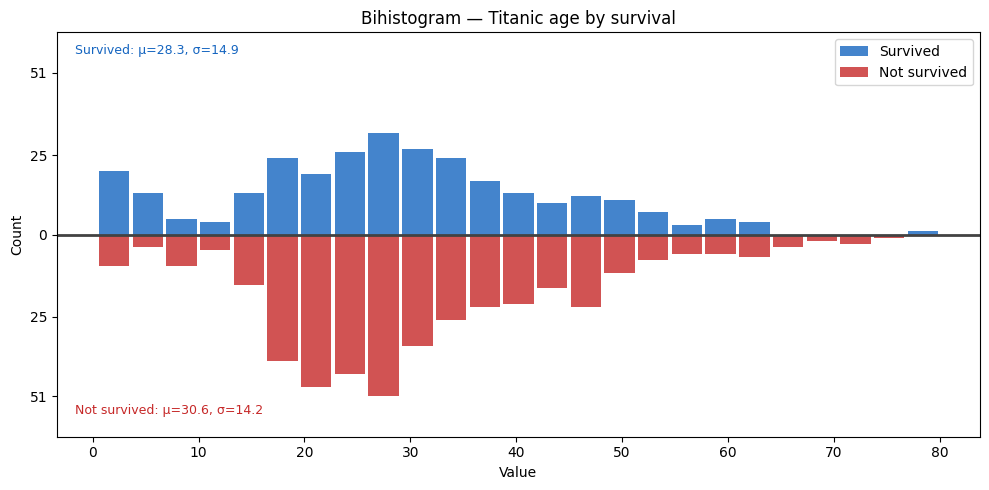

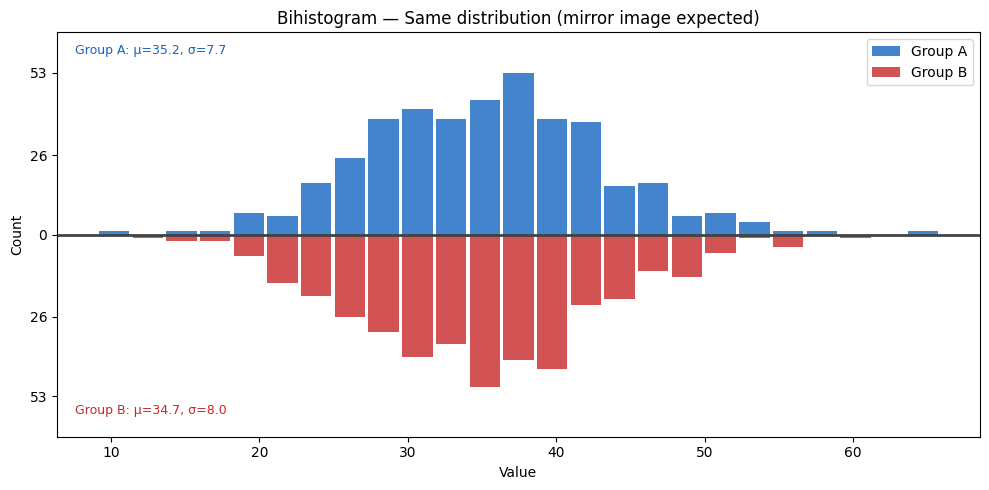

In [3]:
def bihistogram(a, b, label_a="Group A", label_b="Group B",
                bins=30, title="Bihistogram"):
    """Back-to-back histogram comparing two distributions on shared x-axis."""
    fig, ax = plt.subplots(figsize=(10, 5))
    shared_range = (min(a.min(), b.min()), max(a.max(), b.max()))
    counts_a, edges = np.histogram(a, bins=bins, range=shared_range)
    counts_b, _     = np.histogram(b, bins=bins, range=shared_range)
    width = edges[1] - edges[0]
    centers = (edges[:-1] + edges[1:]) / 2

    ax.bar(centers, counts_a,  width=width*0.9, color='#1565C0', alpha=0.8,
           label=label_a, align='center')
    ax.bar(centers, -counts_b, width=width*0.9, color='#C62828', alpha=0.8,
           label=label_b, align='center')

    ax.axhline(0, color='#424242', linewidth=2)
    max_count = max(counts_a.max(), counts_b.max())
    ax.set_ylim(-max_count * 1.25, max_count * 1.25)
    ax.set_yticks([-max_count, -max_count//2, 0, max_count//2, max_count])
    ax.set_yticklabels([str(max_count), str(max_count//2), '0',
                        str(max_count//2), str(max_count)])
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.set_title(title, fontsize=12)
    ax.legend()
    ax.text(0.02, 0.97, f'{label_a}: μ={a.mean():.1f}, σ={a.std():.1f}',
            transform=ax.transAxes, va='top', fontsize=9, color='#1565C0')
    ax.text(0.02, 0.05, f'{label_b}: μ={b.mean():.1f}, σ={b.std():.1f}',
            transform=ax.transAxes, va='bottom', fontsize=9, color='#C62828')
    plt.tight_layout()
    plt.show()

np.random.seed(42)
df = sns.load_dataset('titanic').dropna(subset=['age'])

survived    = df[df['survived']==1]['age'].values
not_survived = df[df['survived']==0]['age'].values

# Case 1: survived vs not survived (location difference expected)
bihistogram(survived, not_survived,
            label_a='Survived', label_b='Not survived',
            bins=25, title='Bihistogram — Titanic age by survival')

# Case 2: synthetic — same distribution (mirror image expected)
a_same = np.random.normal(35, 8, 400)
b_same = np.random.normal(35, 8, 400)
bihistogram(a_same, b_same,
            label_a='Group A', label_b='Group B',
            bins=25, title='Bihistogram — Same distribution (mirror image expected)')

## Key Takeaways

| | |
|---|---|
| **Best for** | Two-sample graphical comparison of distributions |
| **Shared x-axis** | Essential — makes location and spread directly comparable |
| **Group A (top)** | Bars grow upward |
| **Group B (bottom)** | Bars grow downward |
| **Mirror image** | Same distribution — no significant difference |
| **Misaligned peaks** | Location shift — consider t-test or Mann-Whitney U |
| **Different widths** | Variance difference — consider Levene's or F-test |
| **vs overlapping histograms** | Bihistogram is cleaner for two groups; overlapping histograms get cluttered |
| **vs boxplot** | Boxplot gives quantiles; bihistogram gives full shape |